# Therapy Chatbot — Stage 1: Pretraining
**Fully self-contained notebook — no external `.py` files needed.**
Run cells top-to-bottom. All config, model, dataset, and training code is embedded here.

## Cell 1 — Verify GPU & datasets

In [1]:
import torch, os

print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {mem:.1f} GB')

for path in [
    '/kaggle/input/datasets/rohitgr/wikitext/wikitext-103/wiki.train.tokens',
    '/kaggle/input/datasets/rohitgr/wikitext/wikitext-103/wiki.valid.tokens',
    '/kaggle/input/datasets/rohitgr/wikitext/wikitext-103/wiki.test.tokens',
    '/kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv',
]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    print(f'  {"OK" if exists else "MISSING"} ({size:.0f} MB)  {path}')

GPU available: True
GPU: Tesla T4
VRAM: 15.6 GB
  OK (539 MB)  /kaggle/input/datasets/rohitgr/wikitext/wikitext-103/wiki.train.tokens
  OK (1 MB)  /kaggle/input/datasets/rohitgr/wikitext/wikitext-103/wiki.valid.tokens
  OK (1 MB)  /kaggle/input/datasets/rohitgr/wikitext/wikitext-103/wiki.test.tokens
  OK (4667 MB)  /kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv


## Cell 2 — Install dependencies

In [ ]:
!pip install tokenizers --quiet

## Cell 3 — (Optional) Inspect BookCorpus CSV columns

In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv', nrows=3)
print('Columns:', df.columns.tolist())
print(df.head(3))

Columns: ['0']
                                                   0
0  she began getting up first thing in the mornin...
1  caitrin hid the fact that she was a woman behi...
2  she considered strapping down her breasts, and...


## Cell 4 — Config (edit here to change hyperparameters)

In [3]:
"""
All hyperparameters in one place.
Edit values below to change model size, paths, or training settings.
"""
import os

# ── Paths ────────────────────────────────────────────────────────────────────
WIKITEXT_DIR        = '/kaggle/input/datasets/rohitgr/wikitext/wikitext-103'
BOOKCORPUS_CSV      = '/kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv'
OUTPUT_DIR          = '/kaggle/working/therapy_pretrain'
TOKENIZER_PATH      = os.path.join(OUTPUT_DIR, 'tokenizer')
CHECKPOINT_DIR      = os.path.join(OUTPUT_DIR, 'checkpoints')
LOG_DIR             = os.path.join(OUTPUT_DIR, 'logs')

# ── Tokenizer ────────────────────────────────────────────────────────────────
VOCAB_SIZE          = 30_000
MIN_FREQUENCY       = 2
SPECIAL_TOKENS      = ['<pad>', '<unk>', '<bos>', '<eos>']

# ── Data ─────────────────────────────────────────────────────────────────────
MAX_SEQ_LEN         = 512
BOOKCORPUS_MAX_ROWS = 2_000_000   # set None for all rows
BOOKCORPUS_TEXT_COL = 'text'      # ← update if Cell 3 shows a different column name

# ── Model (GPT-2 small equivalent) ───────────────────────────────────────────
N_LAYERS            = 12
N_HEADS             = 12
D_MODEL             = 768
D_FF                = 3072        # 4 * D_MODEL
DROPOUT             = 0.1
MAX_POS             = 1024

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE          = 8           # per GPU; effective = BATCH_SIZE * GRAD_ACCUM
GRAD_ACCUM          = 4           # effective batch size = 32
MAX_EPOCHS          = 2
LR                  = 3e-4
WEIGHT_DECAY        = 0.1
GRAD_CLIP           = 1.0
WARMUP_STEPS        = 2_000
LOG_EVERY           = 100
SAVE_EVERY          = 1_000
EVAL_EVERY          = 1_000
MIXED_PRECISION     = True
SEED                = 42

# Create output directories
for d in [OUTPUT_DIR, TOKENIZER_PATH, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print('Config loaded. Output dir:', OUTPUT_DIR)

Config loaded. Output dir: /kaggle/working/therapy_pretrain


## Cell 5 — Model definition (GPT-2 style decoder-only transformer)

In [4]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert D_MODEL % N_HEADS == 0
        self.n_heads  = N_HEADS
        self.d_head   = D_MODEL // N_HEADS
        self.c_attn   = nn.Linear(D_MODEL, 3 * D_MODEL, bias=True)
        self.c_proj   = nn.Linear(D_MODEL, D_MODEL, bias=True)
        self.attn_drop  = nn.Dropout(DROPOUT)
        self.resid_drop = nn.Dropout(DROPOUT)
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(MAX_POS, MAX_POS)).view(1, 1, MAX_POS, MAX_POS)
        )

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(D_MODEL, dim=2)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scale = 1.0 / math.sqrt(self.d_head)
        att   = (q @ k.transpose(-2, -1)) * scale
        att   = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att   = F.softmax(att, dim=-1)
        att   = self.attn_drop(att)
        out   = att @ v
        out   = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.c_proj(out))


class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1  = nn.Linear(D_MODEL, D_FF)
        self.fc2  = nn.Linear(D_FF, D_MODEL)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x):
        return self.drop(self.fc2(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1  = nn.LayerNorm(D_MODEL)
        self.attn = CausalSelfAttention()
        self.ln2  = nn.LayerNorm(D_MODEL)
        self.ff   = FeedForward()

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.transformer = nn.ModuleDict(dict(
            tok_emb = nn.Embedding(vocab_size, D_MODEL),
            pos_emb = nn.Embedding(MAX_POS, D_MODEL),
            drop    = nn.Dropout(DROPOUT),
            blocks  = nn.ModuleList([TransformerBlock() for _ in range(N_LAYERS)]),
            ln_f    = nn.LayerNorm(D_MODEL),
        ))
        self.lm_head = nn.Linear(D_MODEL, vocab_size, bias=False)
        self.lm_head.weight = self.transformer.tok_emb.weight   # weight tying
        self._init_weights()
        n_params = sum(p.numel() for p in self.parameters())
        print(f'GPTLanguageModel: {n_params / 1e6:.1f}M parameters', flush=True)

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
            elif isinstance(module, nn.LayerNorm):
                nn.init.zeros_(module.bias)
                nn.init.ones_(module.weight)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * N_LAYERS))

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= MAX_POS, f'Sequence length {T} exceeds MAX_POS={MAX_POS}'
        device  = idx.device
        pos     = torch.arange(0, T, dtype=torch.long, device=device)
        tok_emb = self.transformer.tok_emb(idx)
        pos_emb = self.transformer.pos_emb(pos)
        x       = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.blocks:
            x = block(x)
        x      = self.transformer.ln_f(x)
        logits  = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.vocab_size),
                targets.view(-1),
                ignore_index=-1,
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 0.8, top_p: float = 0.9):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -MAX_POS:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cumprobs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_idx_to_remove = cumprobs - F.softmax(sorted_logits, dim=-1) > top_p
            sorted_logits[sorted_idx_to_remove] = float('-inf')
            logits = torch.zeros_like(logits).scatter_(1, sorted_idx, sorted_logits)
            probs      = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx        = torch.cat([idx, next_token], dim=1)
        return idx


print('Model classes defined.')

Model classes defined.


## Cell 6 — Dataset classes

In [5]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from tokenizers import Tokenizer


def load_tokenizer() -> Tokenizer:
    import os
    path = os.path.join(TOKENIZER_PATH, 'tokenizer.json')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Tokenizer not found at {path}.\nRun the tokenizer training cell first.'
        )
    tok = Tokenizer.from_file(path)
    tok.enable_truncation(max_length=MAX_SEQ_LEN + 1)
    return tok


class WikiTextDataset(Dataset):
    """Reads a WikiText .tokens file, tokenizes, chunks into MAX_SEQ_LEN sequences."""
    def __init__(self, split: str, tokenizer: Tokenizer):
        assert split in ('train', 'valid', 'test')
        self.seq_len   = MAX_SEQ_LEN
        self.tokenizer = tokenizer
        path = os.path.join(WIKITEXT_DIR, f'wiki.{split}.tokens')
        if not os.path.exists(path):
            raise FileNotFoundError(f'Not found: {path}')
        print(f'[WikiTextDataset] Tokenizing {split} split …', flush=True)
        all_ids = []
        with open(path, 'r', encoding='utf-8') as f:
            batch = []
            for line in f:
                line = line.strip()
                if not line or line.startswith('='):
                    continue
                batch.append(line)
                if len(batch) == 512:
                    for enc in tokenizer.encode_batch(batch):
                        all_ids.extend(enc.ids)
                    batch = []
            if batch:
                for enc in tokenizer.encode_batch(batch):
                    all_ids.extend(enc.ids)
        self.data = np.array(all_ids, dtype=np.int32)
        n_chunks  = (len(self.data) - 1) // self.seq_len
        self.data = self.data[: n_chunks * self.seq_len + 1]
        print(f'[WikiTextDataset] {split}: {len(self.data):,} tokens → '
              f'{n_chunks:,} chunks of length {self.seq_len}', flush=True)

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        x = torch.from_numpy(self.data[start     : start + self.seq_len].astype(np.int64))
        y = torch.from_numpy(self.data[start + 1 : start + self.seq_len + 1].astype(np.int64))
        return x, y


class BookCorpusDataset(Dataset):
    """Reads BookCorpus CSV, tokenizes every row, chunks into MAX_SEQ_LEN sequences."""
    def __init__(self, tokenizer: Tokenizer):
        if not os.path.exists(BOOKCORPUS_CSV):
            raise FileNotFoundError(f'Not found: {BOOKCORPUS_CSV}')
        self.seq_len = MAX_SEQ_LEN
        print(f'[BookCorpusDataset] Reading CSV … (max_rows={BOOKCORPUS_MAX_ROWS})', flush=True)
        all_ids    = []
        chunk_size = 50_000
        rows_read  = 0
        reader = pd.read_csv(
            BOOKCORPUS_CSV,
            header=None,                        # ← CSV has no header row
            names=[BOOKCORPUS_TEXT_COL],        # ← assign column name ourselves
            chunksize=chunk_size,
            on_bad_lines='skip',
            dtype=str,
        )
        for chunk in reader:
            texts = (
                chunk[BOOKCORPUS_TEXT_COL]
                .dropna().str.strip()
                .loc[lambda s: s.str.len() > 20]
                .tolist()
            )
            for enc in tokenizer.encode_batch(texts):
                all_ids.extend(enc.ids)
            rows_read += len(chunk)
            if rows_read % 200_000 == 0:
                print(f'  … {rows_read:,} rows read, {len(all_ids):,} tokens so far', flush=True)
            if BOOKCORPUS_MAX_ROWS and rows_read >= BOOKCORPUS_MAX_ROWS:
                break
        self.data = np.array(all_ids, dtype=np.int32)
        n_chunks  = (len(self.data) - 1) // self.seq_len
        self.data = self.data[: n_chunks * self.seq_len + 1]
        print(f'[BookCorpusDataset] {len(self.data):,} tokens → '
              f'{n_chunks:,} chunks of length {self.seq_len}', flush=True)

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        x = torch.from_numpy(self.data[start     : start + self.seq_len].astype(np.int64))
        y = torch.from_numpy(self.data[start + 1 : start + self.seq_len + 1].astype(np.int64))
        return x, y


class CombinedDataset(Dataset):
    """Concatenates WikiText and BookCorpus datasets."""
    def __init__(self, wiki_ds: WikiTextDataset, book_ds: BookCorpusDataset):
        self.datasets = [wiki_ds, book_ds]
        self.lengths  = [len(wiki_ds), len(book_ds)]
        self.total    = sum(self.lengths)
        self.offsets  = [0, len(wiki_ds)]

    def __len__(self):
        return self.total

    def __getitem__(self, idx):
        for ds, offset, length in zip(self.datasets, self.offsets, self.lengths):
            if idx < offset + length:
                return ds[idx - offset]
        raise IndexError(idx)


print('Dataset classes defined.')

Dataset classes defined.


## Cell 7 — Train the BPE tokenizer (~5-10 min)

In [6]:
import time
from tokenizers import Tokenizer, models, pre_tokenizers, trainers, processors, decoders


def wiki_lines(split: str):
    path = os.path.join(WIKITEXT_DIR, f'wiki.{split}.tokens')
    if not os.path.exists(path):
        raise FileNotFoundError(f'WikiText file not found: {path}')
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('='):
                yield line


def book_lines():
    if not os.path.exists(BOOKCORPUS_CSV):
        print('BookCorpus CSV not found, skipping.')
        return
    print(f'  Loading BookCorpus CSV (up to {BOOKCORPUS_MAX_ROWS} rows)...')
    df = pd.read_csv(
        BOOKCORPUS_CSV,
        header=None,                     # ← no header row in this CSV
        names=['text'],                  # ← assign a name ourselves
        nrows=BOOKCORPUS_MAX_ROWS,
        on_bad_lines='skip',
        dtype=str,
    )
    for text in df[BOOKCORPUS_TEXT_COL].dropna():
        text = text.strip()
        if len(text) > 20:
            yield text


def sentence_iterator():
    print('  Streaming WikiText train split...')
    yield from wiki_lines('train')
    print('  Streaming BookCorpus...')
    yield from book_lines()


print('=' * 60)
print('Training BPE tokenizer')
print('=' * 60)

tokenizer_obj = Tokenizer(models.BPE(unk_token='<unk>'))
tokenizer_obj.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tokenizer_obj.decoder       = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=MIN_FREQUENCY,
    special_tokens=SPECIAL_TOKENS,
    show_progress=True,
)

t0 = time.time()
tokenizer_obj.train_from_iterator(sentence_iterator(), trainer=trainer)
elapsed = time.time() - t0
print(f'\nTokenizer trained in {elapsed:.1f}s')
print(f'Vocabulary size: {tokenizer_obj.get_vocab_size()}')

bos_id = tokenizer_obj.token_to_id('<bos>')
eos_id = tokenizer_obj.token_to_id('<eos>')
tokenizer_obj.post_processor = processors.TemplateProcessing(
    single='<bos>:0 $A:0 <eos>:0',
    pair='<bos>:0 $A:0 <eos>:0 $B:0 <eos>:0',
    special_tokens=[('<bos>', bos_id), ('<eos>', eos_id)],
)

save_path = os.path.join(TOKENIZER_PATH, 'tokenizer.json')
tokenizer_obj.save(save_path)
print(f'Tokenizer saved to: {save_path}')

Training BPE tokenizer
  Streaming WikiText train split...
  Streaming BookCorpus...
  Loading BookCorpus CSV (up to 2000000 rows)...




Tokenizer trained in 238.5s
Vocabulary size: 30000
Tokenizer saved to: /kaggle/working/therapy_pretrain/tokenizer/tokenizer.json


## Cell 8 — Sanity check tokenizer

In [7]:
tok = load_tokenizer()
text = 'The patient described feelings of anxiety and sadness.'
enc  = tok.encode(text)
print('Input  :', text)
print('Tokens :', enc.tokens)
print('IDs    :', enc.ids)
print('Decoded:', tok.decode(enc.ids))

Input  : The patient described feelings of anxiety and sadness.
Tokens : ['<bos>', 'ĠThe', 'Ġpatient', 'Ġdescribed', 'Ġfeelings', 'Ġof', 'Ġanxiety', 'Ġand', 'Ġsadness', '.', '<eos>']
IDs    : [2, 353, 3637, 2193, 4271, 230, 9386, 228, 10744, 17, 3]
Decoded:  The patient described feelings of anxiety and sadness.


## Cell 9 — Training utilities (LR schedule, validation, checkpoint, logger)

In [8]:
import csv
import math
import time
import random
import numpy as np
import torch


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_lr(step: int, total_steps: int) -> float:
    if step < WARMUP_STEPS:
        return LR * step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return LR * 0.5 * (1.0 + math.cos(math.pi * progress))


@torch.no_grad()
def evaluate(model, val_loader, device, max_batches=100):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    for x, y in val_loader:
        if n_batches >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        with torch.cuda.amp.autocast(enabled=MIXED_PRECISION):
            _, loss = model(x, y)
        total_loss += loss.item()
        n_batches  += 1
    model.train()
    avg_loss = total_loss / max(1, n_batches)
    return avg_loss, math.exp(avg_loss)


def save_checkpoint(model, optimizer, scaler, step, epoch, loss, tag='latest'):
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    path = os.path.join(CHECKPOINT_DIR, f'ckpt_{tag}.pt')
    torch.save({
        'step':       step,
        'epoch':      epoch,
        'model':      model.state_dict(),
        'optimizer':  optimizer.state_dict(),
        'scaler':     scaler.state_dict(),
        'loss':       loss,
        'vocab_size': model.vocab_size,
    }, path)
    print(f'  [Checkpoint saved] {path}', flush=True)


def load_checkpoint(model, optimizer, scaler, tag='latest'):
    path = os.path.join(CHECKPOINT_DIR, f'ckpt_{tag}.pt')
    if not os.path.exists(path):
        return 0, 0
    ckpt = torch.load(path, map_location='cpu')
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scaler.load_state_dict(ckpt['scaler'])
    print(f'  [Checkpoint loaded] step={ckpt["step"]}, epoch={ckpt["epoch"]}', flush=True)
    return ckpt['step'], ckpt['epoch']


class CSVLogger:
    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.path   = path
        self.file   = open(path, 'w', newline='')
        self.writer = csv.writer(self.file)
        self.writer.writerow(['step', 'epoch', 'train_loss', 'val_loss', 'val_ppl', 'lr', 'elapsed_s'])
        self.file.flush()

    def log(self, step, epoch, train_loss, val_loss, val_ppl, lr, elapsed):
        self.writer.writerow([
            step, epoch, f'{train_loss:.4f}',
            f'{val_loss:.4f}' if val_loss else '',
            f'{val_ppl:.2f}'  if val_ppl  else '',
            f'{lr:.6f}', f'{elapsed:.1f}'
        ])
        self.file.flush()

    def close(self):
        self.file.close()


print('Training utilities defined.')

Training utilities defined.


## Cell 10 — Run pretraining (~4-8 hours on T4 for 2 epochs)

In [9]:
# Add this cell at the very top of your training — runs a background thread
# that saves checkpoints to /kaggle/working every 30 minutes automatically
import threading
import time
import shutil

def periodic_commit():
    while True:
        time.sleep(30 * 60)  # every 30 minutes
        try:
            shutil.copy(
                os.path.join(CHECKPOINT_DIR, 'ckpt_best.pt'),
                '/kaggle/working/ckpt_best_backup.pt'
            )
            print('Background save done.', flush=True)
        except Exception as e:
            print(f'Background save failed: {e}', flush=True)

t = threading.Thread(target=periodic_commit, daemon=True)
t.start()
print('Background checkpoint saver started.')

from torch.utils.data import DataLoader

set_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}', flush=True)
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}', flush=True)
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB', flush=True)

# ── Tokenizer ────────────────────────────────────────────────────────────────
print('\nLoading tokenizer …', flush=True)
tokenizer  = load_tokenizer()
vocab_size = tokenizer.get_vocab_size()
print(f'Vocab size: {vocab_size}', flush=True)

# ── Datasets ─────────────────────────────────────────────────────────────────
print('\nBuilding datasets …', flush=True)
wiki_train = WikiTextDataset('train', tokenizer)
wiki_valid = WikiTextDataset('valid', tokenizer)

book_available = os.path.exists(BOOKCORPUS_CSV)
if book_available:
    book_train = BookCorpusDataset(tokenizer)
    train_ds   = CombinedDataset(wiki_train, book_train)
else:
    print('BookCorpus not found — training on WikiText only.', flush=True)
    train_ds = wiki_train

print(f'\nTraining samples  : {len(train_ds):,}', flush=True)
print(f'Validation samples: {len(wiki_valid):,}', flush=True)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == 'cuda'),
    drop_last=True,
)
val_loader = DataLoader(
    wiki_valid,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == 'cuda'),
    drop_last=False,
)

# ── Model ─────────────────────────────────────────────────────────────────────
print('\nBuilding model …', flush=True)
model = GPTLanguageModel(vocab_size).to(device)

# ── Optimizer (AdamW with selective weight decay) ─────────────────────────────
decay_params    = [p for n, p in model.named_parameters() if p.requires_grad and p.dim() >= 2]
no_decay_params = [p for n, p in model.named_parameters() if p.requires_grad and p.dim() < 2]
optimizer = torch.optim.AdamW(
    [
        {'params': decay_params,    'weight_decay': WEIGHT_DECAY},
        {'params': no_decay_params, 'weight_decay': 0.0},
    ],
    lr=LR, betas=(0.9, 0.95), eps=1e-8,
)
scaler = torch.cuda.amp.GradScaler(enabled=MIXED_PRECISION)

# ── Resume from checkpoint if available ──────────────────────────────────────
global_step, start_epoch = load_checkpoint(model, optimizer, scaler)

# ── LR schedule totals ───────────────────────────────────────────────────────
steps_per_epoch = len(train_loader) // GRAD_ACCUM
total_steps     = steps_per_epoch * MAX_EPOCHS
print(f'\nSteps per epoch: {steps_per_epoch:,}', flush=True)
print(f'Total steps    : {total_steps:,}', flush=True)

# ── Logger ───────────────────────────────────────────────────────────────────
log_path = os.path.join(LOG_DIR, 'pretrain_log.csv')
logger   = CSVLogger(log_path)

# ── Training loop ────────────────────────────────────────────────────────────
print('\n' + '=' * 60, flush=True)
print('Starting pretraining', flush=True)
print('=' * 60, flush=True)

t_start      = time.time()
model.train()
best_val_ppl = float('inf')

for epoch in range(start_epoch, MAX_EPOCHS):
    running_loss = 0.0
    accum_steps  = 0
    optimizer.zero_grad()

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=MIXED_PRECISION):
            _, loss = model(x, y)
            loss    = loss / GRAD_ACCUM

        scaler.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM
        accum_steps  += 1

        if accum_steps == GRAD_ACCUM:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            lr = get_lr(global_step, total_steps)
            for pg in optimizer.param_groups:
                pg['lr'] = lr

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            avg_loss     = running_loss / GRAD_ACCUM
            running_loss = 0.0
            accum_steps  = 0
            global_step += 1
            elapsed      = time.time() - t_start

            if global_step % LOG_EVERY == 0:
                print(
                    f'Epoch {epoch+1}/{MAX_EPOCHS}  '
                    f'step {global_step:>6d}/{total_steps}  '
                    f'loss {avg_loss:.4f}  '
                    f'lr {lr:.2e}  '
                    f'elapsed {elapsed/60:.1f}min',
                    flush=True,
                )
                logger.log(global_step, epoch + 1, avg_loss, None, None, lr, elapsed)

            if global_step % EVAL_EVERY == 0:
                val_loss, val_ppl = evaluate(model, val_loader, device)
                print(
                    f'  >> Validation — loss {val_loss:.4f}  perplexity {val_ppl:.2f}',
                    flush=True,
                )
                logger.log(global_step, epoch + 1, avg_loss, val_loss, val_ppl, lr, elapsed)
                if val_ppl < best_val_ppl:
                    best_val_ppl = val_ppl
                    save_checkpoint(model, optimizer, scaler, global_step, epoch + 1, val_loss, tag='best')
                    print(f'  >> New best PPL: {best_val_ppl:.2f}', flush=True)

            if global_step % SAVE_EVERY == 0:
                save_checkpoint(model, optimizer, scaler, global_step, epoch + 1, avg_loss, tag='latest')

# ── Final eval ───────────────────────────────────────────────────────────────
print('\nFinal validation …', flush=True)
val_loss, val_ppl = evaluate(model, val_loader, device, max_batches=len(val_loader))
print(f'Final validation — loss {val_loss:.4f}  perplexity {val_ppl:.2f}', flush=True)
save_checkpoint(model, optimizer, scaler, global_step, MAX_EPOCHS, val_loss, tag='final')
logger.close()

total_time = (time.time() - t_start) / 60
print(f'\nPretraining complete in {total_time:.1f} minutes', flush=True)
print(f'Best validation perplexity : {best_val_ppl:.2f}', flush=True)
print(f'Final validation perplexity: {val_ppl:.2f}', flush=True)
print(f'Log saved to: {log_path}', flush=True)

Background checkpoint saver started.
Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB

Loading tokenizer …
Vocab size: 30000

Building datasets …
[WikiTextDataset] Tokenizing train split …
[WikiTextDataset] train: 114,272,257 tokens → 223,188 chunks of length 512
[WikiTextDataset] Tokenizing valid split …
[WikiTextDataset] valid: 239,105 tokens → 467 chunks of length 512
[BookCorpusDataset] Reading CSV … (max_rows=2000000)
  … 200,000 rows read, 19,498,012 tokens so far
  … 400,000 rows read, 37,690,077 tokens so far
  … 600,000 rows read, 62,143,512 tokens so far
  … 800,000 rows read, 80,694,707 tokens so far
  … 1,000,000 rows read, 99,772,780 tokens so far
  … 1,200,000 rows read, 118,154,315 tokens so far
  … 1,400,000 rows read, 136,275,289 tokens so far
  … 1,600,000 rows read, 153,832,109 tokens so far
  … 1,800,000 rows read, 171,581,293 tokens so far
  … 2,000,000 rows read, 190,000,414 tokens so far
[BookCorpusDataset] 190,000,129 tokens → 371,094 chunks of length 512

Training 

/tmp/ipykernel_55/340943252.py:87: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=MIXED_PRECISION)
/tmp/ipykernel_55/340943252.py:119: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=MIXED_PRECISION):


Epoch 1/2  step    100/37142  loss 8.5763  lr 1.48e-05  elapsed 2.3min
Epoch 1/2  step    200/37142  loss 7.3004  lr 2.98e-05  elapsed 4.7min
Epoch 1/2  step    300/37142  loss 6.6819  lr 4.48e-05  elapsed 7.2min
Epoch 1/2  step    400/37142  loss 6.4706  lr 5.98e-05  elapsed 9.6min
Epoch 1/2  step    500/37142  loss 6.2603  lr 7.49e-05  elapsed 12.1min
Epoch 1/2  step    600/37142  loss 6.0583  lr 8.98e-05  elapsed 14.5min
Epoch 1/2  step    700/37142  loss 6.1521  lr 1.05e-04  elapsed 17.0min
Epoch 1/2  step    800/37142  loss 5.7689  lr 1.20e-04  elapsed 19.4min
Epoch 1/2  step    900/37142  loss 5.7875  lr 1.35e-04  elapsed 21.9min
Background save failed: [Errno 2] No such file or directory: '/kaggle/working/therapy_pretrain/checkpoints/ckpt_best.pt'
Epoch 1/2  step   1000/37142  loss 5.8803  lr 1.50e-04  elapsed 24.4min


/tmp/ipykernel_55/3218084262.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=MIXED_PRECISION):


  >> Validation — loss 5.9483  perplexity 383.10
  [Checkpoint saved] /kaggle/working/therapy_pretrain/checkpoints/ckpt_best.pt
  >> New best PPL: 383.10
  [Checkpoint saved] /kaggle/working/therapy_pretrain/checkpoints/ckpt_latest.pt
Epoch 1/2  step   1100/37142  loss 5.6647  lr 1.65e-04  elapsed 27.0min
Epoch 1/2  step   1200/37142  loss 5.5521  lr 1.80e-04  elapsed 29.5min
Epoch 1/2  step   1300/37142  loss 5.5849  lr 1.95e-04  elapsed 31.9min
Epoch 1/2  step   1400/37142  loss 5.5027  lr 2.10e-04  elapsed 34.4min
Epoch 1/2  step   1500/37142  loss 5.4376  lr 2.25e-04  elapsed 36.8min
Epoch 1/2  step   1600/37142  loss 5.2405  lr 2.40e-04  elapsed 39.3min
Epoch 1/2  step   1700/37142  loss 5.3510  lr 2.55e-04  elapsed 41.7min
Epoch 1/2  step   1800/37142  loss 5.2938  lr 2.70e-04  elapsed 44.2min
Epoch 1/2  step   1900/37142  loss 5.1234  lr 2.85e-04  elapsed 46.6min
Epoch 1/2  step   2000/37142  loss 5.1452  lr 3.00e-04  elapsed 49.1min
  >> Validation — loss 5.1426  perplexity 171

KeyboardInterrupt: 

## Cell 11 — Evaluate: final perplexity on test set + loss curves + sample generation

GPTLanguageModel: 108.9M parameters
Loaded checkpoint: /kaggle/working/therapy_pretrain/checkpoints/ckpt_best.pt  (step=25000)

Evaluating on WikiText test split …
[WikiTextDataset] Tokenizing test split …
[WikiTextDataset] test: 271,361 tokens → 530 chunks of length 512


/tmp/ipykernel_55/1554637737.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=MIXED_PRECISION):


  … 50 batches evaluated, running PPL = 29.46

Test loss       : 3.3862
Test perplexity : 29.55
Loss curves saved to: /kaggle/working/therapy_pretrain/logs/pretrain_curves.png


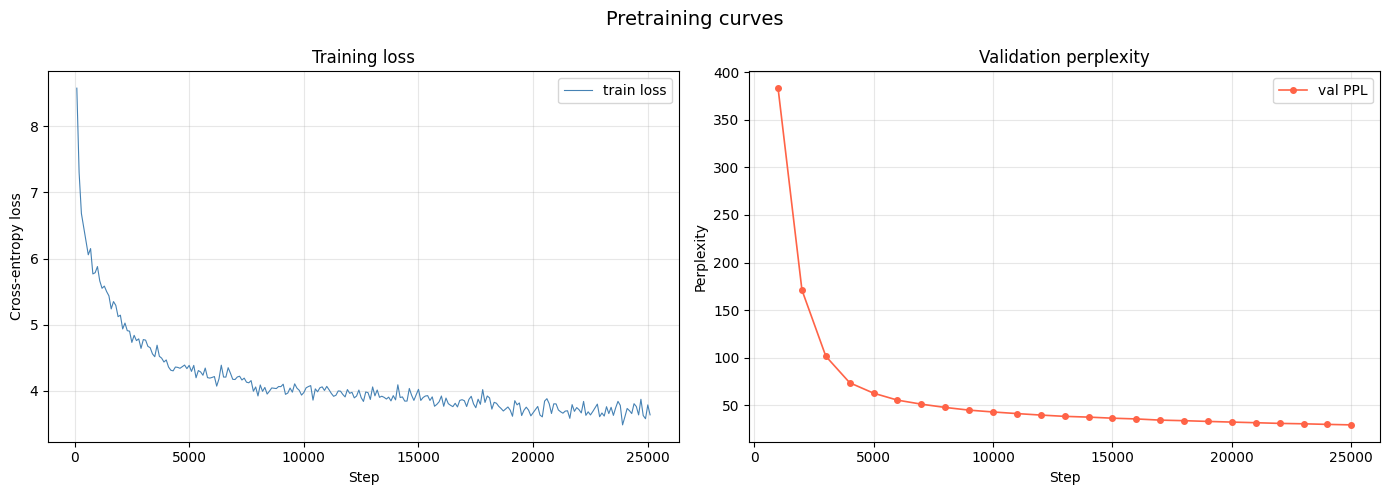


Generated samples (pretrained model)

Prompt: The history of science shows
Output:  The history of science shows S @-@ 16 's Modeo @-@ Argonautica is a short @-@ lived  @-@ type bird found in Europe and North America , and is a member of the family Sangoda genus of the family  . It was first described by Edward Hughes in 1785 and first described in 1826 . It is a small @-@ bodied bird with short , low bill , short , and a broad , well @-@ defined bill , with a wide , broad bill , a broad , sharp
----------------------------------------

Prompt: Mental health is important because
Output:  Mental health is important because " I was getting sick of it . It was very bad . I was doing that . I 'd said that because I could have been sick of it . I was doing it . I thought it was a very good job . I wanted to get sick of it and , oh , I wanted to get sick of it . " The government has stated that it is not a step in the path of " reconciliation " because it was said that " this was the way it

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


# ── Load best checkpoint ──────────────────────────────────────────────────────
def load_best_model(device):
    tok        = load_tokenizer()
    vs         = tok.get_vocab_size()
    mdl        = GPTLanguageModel(vs).to(device)
    ckpt_path  = os.path.join(CHECKPOINT_DIR, 'ckpt_best.pt')
    if not os.path.exists(ckpt_path):
        ckpt_path = os.path.join(CHECKPOINT_DIR, 'ckpt_final.pt')
    ckpt = torch.load(ckpt_path, map_location=device)
    mdl.load_state_dict(ckpt['model'])
    print(f'Loaded checkpoint: {ckpt_path}  (step={ckpt["step"]})')
    return mdl, tok


@torch.no_grad()
def full_perplexity(mdl, loader, device):
    mdl.eval()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.cuda.amp.autocast(enabled=MIXED_PRECISION):
            _, loss = mdl(x, y)
        total_loss += loss.item()
        n += 1
        if n % 50 == 0:
            print(f'  … {n} batches evaluated, running PPL = {math.exp(total_loss/n):.2f}')
    avg = total_loss / n
    return avg, math.exp(avg)


def plot_loss_curves():
    log_path = os.path.join(LOG_DIR, 'pretrain_log.csv')
    if not os.path.exists(log_path):
        print('No log file found — skipping plot.')
        return
    df = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Pretraining curves', fontsize=14)
    train_df = df[df['train_loss'].notna()]
    axes[0].plot(train_df['step'], train_df['train_loss'], color='steelblue', linewidth=0.8, label='train loss')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title('Training loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    val_df = df[df['val_ppl'].notna()]
    if not val_df.empty:
        axes[1].plot(val_df['step'], val_df['val_ppl'], color='tomato', linewidth=1.2,
                     marker='o', markersize=4, label='val PPL')
        axes[1].set_xlabel('Step'); axes[1].set_ylabel('Perplexity')
        axes[1].set_title('Validation perplexity'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    out_path = os.path.join(LOG_DIR, 'pretrain_curves.png')
    plt.savefig(out_path, dpi=150)
    print(f'Loss curves saved to: {out_path}')
    plt.show()


def generate_samples(mdl, tok, device, prompts=None, max_new=100):
    if prompts is None:
        prompts = [
            'The history of science shows',
            'Mental health is important because',
            'When people feel anxious, they often',
            'The relationship between stress and',
        ]
    mdl.eval()
    print('\n' + '=' * 60)
    print('Generated samples (pretrained model)')
    print('=' * 60)
    bos_id = tok.token_to_id('<bos>')
    for prompt in prompts:
        enc  = tok.encode(prompt)
        ids  = torch.tensor([[bos_id] + enc.ids], dtype=torch.long, device=device)
        out  = mdl.generate(ids, max_new_tokens=max_new, temperature=0.8, top_p=0.9)
        text = tok.decode(out[0].tolist(), skip_special_tokens=True)
        print(f'\nPrompt: {prompt}')
        print(f'Output: {text}')
        print('-' * 40)


# ── Run evaluation ────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
eval_model, eval_tok = load_best_model(device)

print('\nEvaluating on WikiText test split …')
test_ds     = WikiTextDataset('test', eval_tok)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loss, test_ppl = full_perplexity(eval_model, test_loader, device)
print(f'\nTest loss       : {test_loss:.4f}')
print(f'Test perplexity : {test_ppl:.2f}')

plot_loss_curves()
generate_samples(eval_model, eval_tok, device)

## Cell 12 — List saved checkpoints

In [11]:
import os
ckpt_dir = CHECKPOINT_DIR
print(f'Checkpoints in: {ckpt_dir}\n')
for f in sorted(os.listdir(ckpt_dir)):
    size = os.path.getsize(os.path.join(ckpt_dir, f)) / 1e6
    print(f'  {f}  ({size:.0f} MB)')

Checkpoints in: /kaggle/working/therapy_pretrain/checkpoints

  ckpt_best.pt  (1357 MB)
  ckpt_latest.pt  (1357 MB)


In [ ]:
import pandas as pd 
df = pd.read_csv('/kaggle/input/datasets/nishantsingh96/refined-bookcorpus-dataset/BookCorpus3.csv', nrows=2) 
print(df.columns.tolist()) 
print(df.head(2))

In [12]:
import shutil
import os

# Zip the entire checkpoint directory
zip_path = '/kaggle/working/therapy_pretrain/checkpoints'
shutil.make_archive(zip_path, 'zip', CHECKPOINT_DIR)
print(f'Zipped to: {zip_path}.zip')

# Also zip the tokenizer (you'll need it for fine-tuning)
zip_tok = '/kaggle/working/therapy_pretrain/tokenizer'
shutil.make_archive(zip_tok, 'zip', TOKENIZER_PATH)
print(f'Zipped to: {zip_tok}.zip')

# Show file sizes
for f in [zip_path + '.zip', zip_tok + '.zip']:
    size = os.path.getsize(f) / 1e6
    print(f'  {os.path.basename(f)}: {size:.0f} MB')

Zipped to: /kaggle/working/therapy_pretrain/checkpoints.zip
Zipped to: /kaggle/working/therapy_pretrain/tokenizer.zip
  checkpoints.zip: 2392 MB
  tokenizer.zip: 0 MB


In [ ]:
# Step 1 — Install PyDrive2
!pip install pydrive2 --quiet

In [ ]:
# Step 2 — Authenticate and upload
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
import os

# Authenticate — this will print a URL, open it, sign in with Google,
# copy the verification code and paste it back here
gauth = GoogleAuth()
gauth.CommandLineAuth()

drive = GoogleDrive(gauth)

# Upload ckpt_best.pt
print('Uploading ckpt_best.pt ...')
f1 = drive.CreateFile({'title': 'ckpt_best.pt'})
f1.SetContentFile(os.path.join(CHECKPOINT_DIR, 'ckpt_best.pt'))
f1.Upload()
print(f'Done! Drive link: https://drive.google.com/file/d/{f1["id"]}')

# Upload tokenizer.json
print('Uploading tokenizer.json ...')
f2 = drive.CreateFile({'title': 'tokenizer.json'})
f2.SetContentFile(os.path.join(TOKENIZER_PATH, 'tokenizer.json'))
f2.Upload()
print(f'Done! Drive link: https://drive.google.com/file/d/{f2["id"]}')

print('\nBoth files uploaded. Download them directly from the links above.')

In [13]:
import os

zip_path = '/kaggle/working/therapy_pretrain/checkpoints.zip'
chunk_size = 500 * 1024 * 1024  # 500 MB

with open(zip_path, 'rb') as f:
    chunk_num = 0
    while True:
        chunk = f.read(chunk_size)
        if not chunk:
            break
        chunk_file = f'/kaggle/working/part_{chunk_num}.bin'
        with open(chunk_file, 'wb') as cf:
            cf.write(chunk)
        print(f'part_{chunk_num}.bin  —  {os.path.getsize(chunk_file)/1e6:.0f} MB')
        chunk_num += 1

print(f'\nDone. Download each part_ file from the Output tab.')

part_0.bin  —  524 MB
part_1.bin  —  524 MB
part_2.bin  —  524 MB
part_3.bin  —  524 MB
part_4.bin  —  295 MB

Done. Download each part_ file from the Output tab.


In [14]:
save_checkpoint(model, optimizer, scaler, global_step, epoch+1, val_loss, tag='final')

print("Saved!")

  [Checkpoint saved] /kaggle/working/therapy_pretrain/checkpoints/ckpt_final.pt
Saved!


In [15]:
import os
from IPython.display import FileLink

# First zip the folder
os.system('zip -r /kaggle/working/therapy_pretrain.zip /kaggle/working/therapy_pretrain/')

# This generates a clickable download link in the cell output
FileLink('/kaggle/working/therapy_pretrain.zip')

  adding: kaggle/working/therapy_pretrain/ (stored 0%)
  adding: kaggle/working/therapy_pretrain/checkpoints.zip (stored 0%)
  adding: kaggle/working/therapy_pretrain/tokenizer/ (stored 0%)
  adding: kaggle/working/therapy_pretrain/tokenizer/tokenizer.json (deflated 83%)
  adding: kaggle/working/therapy_pretrain/logs/ (stored 0%)
  adding: kaggle/working/therapy_pretrain/logs/pretrain_curves.png (deflated 13%)
  adding: kaggle/working/therapy_pretrain/logs/pretrain_log.csv (deflated 66%)
  adding: kaggle/working/therapy_pretrain/checkpoints/ (stored 0%)
  adding: kaggle/working/therapy_pretrain/checkpoints/ckpt_best.pt (deflated 12%)
  adding: kaggle/working/therapy_pretrain/checkpoints/ckpt_final.pt (deflated 12%)
  adding: kaggle/working/therapy_pretrain/checkpoints/ckpt_latest.pt (deflated 12%)
  adding: kaggle/working/therapy_pretrain/tokenizer.zip (stored 0%)


/kaggle/working/therapy_pretrain.zip

In [16]:
import os

os.makedirs('/kaggle/working/essential/', exist_ok=True)

os.system('cp /kaggle/working/therapy_pretrain/checkpoints/ckpt_best.pt /kaggle/working/essential/')
os.system('cp /kaggle/working/therapy_pretrain/tokenizer/tokenizer.json /kaggle/working/essential/')

os.system('zip -r /kaggle/working/essential.zip /kaggle/working/essential/')

print(f"Model  : {os.path.getsize('/kaggle/working/essential/ckpt_best.pt') / 1e6:.1f} MB")
print(f"Tokenizer: {os.path.getsize('/kaggle/working/essential/tokenizer.json') / 1e6:.1f} MB")
print(f"Zip total: {os.path.getsize('/kaggle/working/essential.zip') / 1e6:.1f} MB")
print("\nNow go to the Output tab (right panel) and download essential.zip")

  adding: kaggle/working/essential/ (stored 0%)
  adding: kaggle/working/essential/ckpt_best.pt (deflated 12%)
  adding: kaggle/working/essential/tokenizer.json (deflated 83%)
Model  : 1357.1 MB
Tokenizer: 2.1 MB
Zip total: 1196.0 MB

Now go to the Output tab (right panel) and download essential.zip


In [18]:
import os

# Delete existing essential folder and zip files
os.system('rm -rf /kaggle/working/essential/')
os.system('rm -f /kaggle/working/essential.zip')
os.system('rm -f /kaggle/working/part_*.bin')

print("Cleaned up old files")

# Copy essential files to a fresh folder
os.makedirs('/kaggle/working/essential/', exist_ok=True)
os.system('cp /kaggle/working/therapy_pretrain/checkpoints/ckpt_best.pt /kaggle/working/essential/')
os.system('cp /kaggle/working/therapy_pretrain/tokenizer/tokenizer.json /kaggle/working/essential/')

print(f"Model    : {os.path.getsize('/kaggle/working/essential/ckpt_best.pt') / 1e6:.1f} MB")
print(f"Tokenizer: {os.path.getsize('/kaggle/working/essential/tokenizer.json') / 1e6:.1f} MB")

# Split into 200MB chunks
os.system('zip -r /kaggle/working/essential.zip /kaggle/working/essential/')
os.system('split -b 200m /kaggle/working/essential.zip /kaggle/working/part_')

# Rename to .zip extension so Kaggle shows them
for f in sorted(os.listdir('/kaggle/working/')):
    if f.startswith('part_') and not f.endswith('.zip'):
        os.rename(f'/kaggle/working/{f}', f'/kaggle/working/{f}.zip')

# Show all parts
parts = sorted([f for f in os.listdir('/kaggle/working/') if f.startswith('part_')])
for p in parts:
    print(f"{p}: {os.path.getsize(f'/kaggle/working/{p}') / 1e6:.1f} MB")

print(f"\nTotal parts: {len(parts)} — download all from the Output tab then reassemble")

Cleaned up old files
Model    : 1357.1 MB
Tokenizer: 2.1 MB
  adding: kaggle/working/essential/ (stored 0%)
  adding: kaggle/working/essential/ckpt_best.pt (deflated 12%)
  adding: kaggle/working/essential/tokenizer.json (deflated 83%)
part_aa.zip: 209.7 MB
part_ab.zip: 209.7 MB
part_ac.zip: 209.7 MB
part_ad.zip: 209.7 MB
part_ae.zip: 209.7 MB
part_af.zip: 147.4 MB

Total parts: 6 — download all from the Output tab then reassemble
Background save done.
